# 06 - Evaluation and Error Analysis
Goal: train the best model (ResNet + weighted loss), save it to disk, then evaluate it in depth -
confusion matrix, precision/recall/F1, and a gallery of misclassified images with hypotheses.

## Setup, train, and save the best model
Rebuild the full pipeline (from notebook 05), train ResNet + weighted loss once, and save the weights
to a .pt file so the model survives kernel restarts and Project 2 can load it later.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import random
from torchvision import models, transforms
from torch.utils.data import DataLoader
from medmnist import DermaMNIST

def set_seed(seed=42):
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
set_seed(42)

resnet_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_data = DermaMNIST(split="train", download=True, size=28, transform=resnet_transform)
val_data   = DermaMNIST(split="val",   download=True, size=28, transform=resnet_transform)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=32, shuffle=False)

counts = np.unique(train_data.labels.flatten(), return_counts=True)[1]
weights = 1.0 / counts
weights = weights / weights.sum() * len(counts)
class_weights = torch.tensor(weights, dtype=torch.float32)

model = models.resnet18(weights="IMAGENET1K_V1")
for p in model.parameters():
    p.requires_grad = False
model.fc = nn.Linear(512, 7)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

for epoch in range(3):
    model.train()
    running = 0.0
    for images, labels in train_loader:
        labels = labels.squeeze()
        loss = criterion(model(images), labels)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        running += loss.item()
    print(f"epoch {epoch}  train loss {running/len(train_loader):.4f}")

torch.save(model.state_dict(), "skinsight_resnet_weighted.pt")
print("model trained and saved to skinsight_resnet_weighted.pt")

epoch 0  train loss 1.6198
epoch 1  train loss 1.3270
epoch 2  train loss 1.2412
model trained and saved to skinsight_resnet_weighted.pt


## Model saved
`torch.save(model.state_dict(), ...)` writes all learned parameter values to a .pt file - the standard
PyTorch way to persist a model. It survives kernel restarts, and Project 2 will load these exact weights.
.pt files are large and regenerable, so they are gitignored, not committed.

## Confusion matrix
A 7x7 grid: rows = true class, columns = predicted class. The diagonal is correct predictions; every
off-diagonal cell is a mistake, showing WHICH classes get confused for which. This reveals error patterns
that accuracy hides - e.g. which class melanoma gets mistaken for.

In [2]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        labels = labels.squeeze()
        preds = model(images).argmax(dim=1)
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

cm = confusion_matrix(all_labels, all_preds)
print(cm)

[[ 23   8   1   0   1   0   0]
 [ 15  30   2   0   3   0   2]
 [ 31  19  28   1  24   3   4]
 [  3   4   0   5   0   0   0]
 [ 21   3   7   4  62   4  10]
 [ 30  31  34  11 123 383  59]
 [  1   2   0   0   0   0  11]]


## Reading the confusion matrix
- Melanoma (row 4): 62/111 correct. Its biggest error (21) goes to class 0 - another malignant class,
  a "safer" confusion than mistaking it for benign. Only 4 melanomas were called nevi (the dangerous miss).
- Predicted-melanoma column: 123 true nevi were flagged as melanoma - false alarms. The weighted model
  over-predicts melanoma, trading false alarms for catching real ones. Clinically defensible: a false alarm
  (unnecessary biopsy) is far less costly than a missed melanoma.
- Nevi errors scatter across all classes - the majority class no longer dominates, the intended effect of weighting.
Key point: the confusion matrix shows error SEVERITY and direction, not just error rate. Not all mistakes are equal.

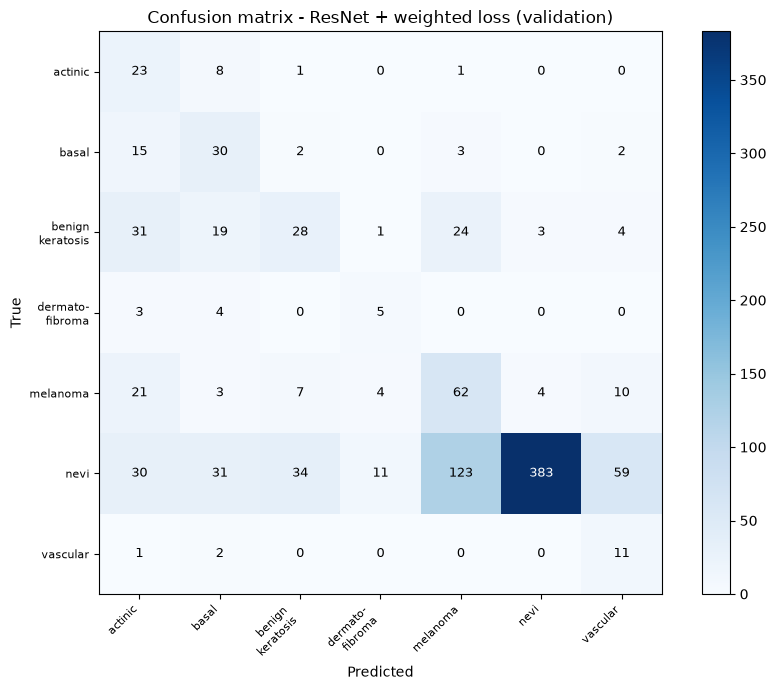

In [3]:
import numpy as np

class_short = ["actinic", "basal", "benign\nkeratosis", "dermato-\nfibroma", "melanoma", "nevi", "vascular"]

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(np.arange(7)); ax.set_yticks(np.arange(7))
ax.set_xticklabels(class_short, fontsize=8); ax.set_yticklabels(class_short, fontsize=8)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion matrix - ResNet + weighted loss (validation)")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# write the count in each cell
for i in range(7):
    for j in range(7):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=9)

plt.colorbar(im)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## Reading the heatmap
The diagonal cells (true = predicted) are the correct predictions: nevi = 383, melanoma = 62, and smaller
counts for the rest. Because nevi (383) dwarfs every other value, it dominates the colour scale and washes
the rest of the grid pale - so the diagonal is NOT visually distinct here. This is the raw-count heatmap's
weakness on imbalanced data: one large class hijacks the colouring (the same way accuracy is hijacked by the
majority class). The off-diagonal cells at (true nevi -> predicted melanoma) = 123 and (true melanoma ->
predicted actinic) = 21 are still the notable error patterns. A row-normalised version (next) fixes the
colour-scale problem.

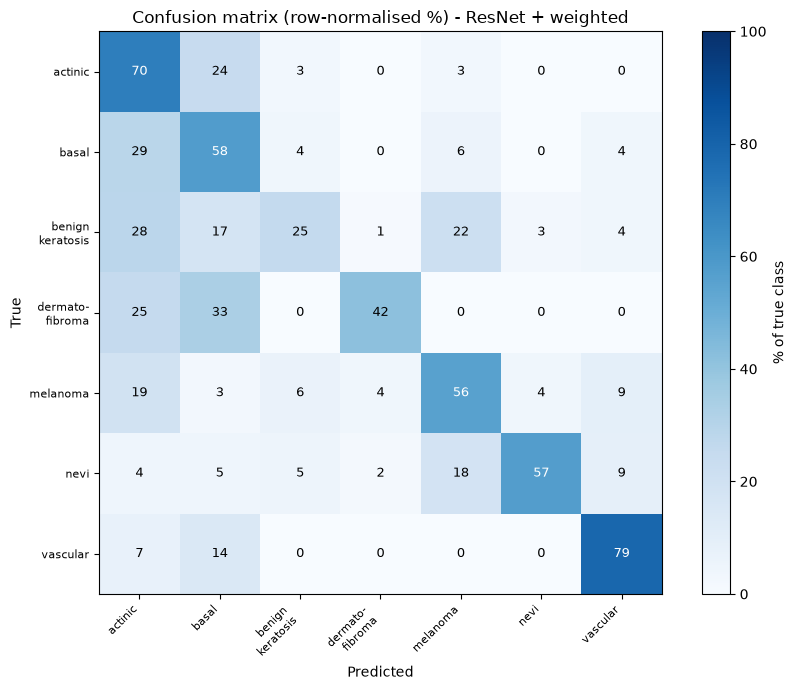

In [4]:
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100   # each row -> % of that true class

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=100)

ax.set_xticks(np.arange(7)); ax.set_yticks(np.arange(7))
ax.set_xticklabels(class_short, fontsize=8); ax.set_yticklabels(class_short, fontsize=8)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion matrix (row-normalised %) - ResNet + weighted")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

for i in range(7):
    for j in range(7):
        ax.text(j, i, f"{cm_norm[i, j]:.0f}", ha="center", va="center",
                color="white" if cm_norm[i, j] > 50 else "black", fontsize=9)

plt.colorbar(im, label="% of true class")
plt.tight_layout()
plt.savefig("confusion_matrix_normalised.png", dpi=150, bbox_inches="tight")
plt.show()

## Reading the normalised matrix
The diagonal now shows each class's recall directly: actinic 70%, basal 58%, benign keratosis 25%,
dermatofibroma 42%, melanoma 56%, nevi 57%, vascular 79%. Colour is no longer hijacked by nevi's size.
Error patterns, now proportional:
- Melanoma: 56% caught; 19% misread as actinic (another malignant class - a safer confusion), only 4% as
  nevi (the dangerous benign miss). Reassuring error direction.
- "Actinic" column acts as a catch-all: basal, benign, dermatofibroma, and melanoma all leak ~19-29% into it.
- Benign keratosis is the weakest class (25%), with 22% bleeding into melanoma (false alarms).
Takeaway: the model's errors are mostly between visually similar or same-severity classes, and it errs toward
over-flagging danger (safer for screening) rather than missing it.